In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# Generator
def get_generator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.BatchNorm1d(output_dim),
        nn.ReLU(inplace=True),
    )


class Generator(nn.Module):
    def __init__(self, z_dim, im_dim, hidden_dim=128):
        super(Generator, self).__init__()

        self.gen = nn.Sequential(
            get_generator_block(z_dim, hidden_dim),
            get_generator_block(hidden_dim, hidden_dim * 2),
            get_generator_block(hidden_dim * 2, hidden_dim * 4),
            get_generator_block(hidden_dim * 4, hidden_dim * 8),
            nn.Linear(hidden_dim * 8, im_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.gen(x)


# Discriminator
def get_discriminator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.LeakyReLU(0.2, inplace=True)
    )


class Discriminator(nn.Module):
    def __init__(self, im_dim, hidden_dim=128):
        super(Discriminator, self).__init__()

        self.disc = nn.Sequential(
            get_discriminator_block(im_dim, hidden_dim * 4),
            get_discriminator_block(hidden_dim * 4, hidden_dim * 2),
            get_discriminator_block(hidden_dim * 2, hidden_dim),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.disc(x)


# SMOTified-GAN (Multi-class Extension)
class SMOTifiedGAN:

    def __init__(
        self,
        k_neighbors=5,
        random_state=42,
        verbose=True
    ):

        self.k_neighbors = k_neighbors
        self.random_state = random_state
        self.verbose = verbose

        self.device = (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    def fit_resample(
        self,
        df,
        label_col="label_3",
        epochs=50,
        batch_size=512,
        lr=0.0001
    ):

        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)

        # Column handling
        id_cols = ["user_id", "course_id"]

        feature_cols = [
            c for c in df.columns
            if c not in id_cols + [label_col]
        ]

        n_features = len(feature_cols)

        # Standard Scaling
        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(
            df[feature_cols].values
        )

        y = df[label_col].astype(str).values

        # Class statistics
        classes, counts = np.unique(y, return_counts=True)

        majority_class = classes[np.argmax(counts)]

        max_count = counts.max()

        minority_classes = [
            cls for cls in classes
            if cls != majority_class
        ]

        if self.verbose:
            print("\n========== SMOTified-GAN ==========")
            print(f"Device: {self.device}")
            print(f"Majority class: {majority_class}")
            print("\nClass distribution BEFORE:")

            for cls, cnt in zip(classes, counts):
                print(f"Class {cls}: {cnt}")

        # Store generated samples
        synthetic_dfs = []

        # Process each minority class independently
        for cls in minority_classes:

            if self.verbose:
                print(f"\n===================================")
                print(f"Processing minority class {cls}")

            # Extract minority + majority
            X_min = X_scaled[y == cls]

            X_maj = X_scaled[y == majority_class]

            n_min = len(X_min)
            n_maj = len(X_maj)

            if self.verbose:
                print(f"Minority samples : {n_min}")
                print(f"Majority samples : {n_maj}")

            if n_min < 2:
                print(f"Skip class {cls} (too few samples)")
                continue

            # Prepare SMOTE dataset
            # minority = 0
            # majority = 1
            X_sub = np.vstack([X_min, X_maj])

            y_sub = np.array(
                [0] * n_min +
                [1] * n_maj
            )

            # SMOTE
            k_eff = max(
                1,
                min(self.k_neighbors, n_min - 1)
            )

            smoter = SMOTE(
                sampling_strategy='not majority',
                k_neighbors=k_eff,
                random_state=self.random_state
            )

            X_res, y_res = smoter.fit_resample(
                X_sub,
                y_sub
            )

           
            X_seed_samples = X_res[len(X_sub):]

            if len(X_seed_samples) == 0:
                print("No SMOTE samples generated")
                continue

            if self.verbose:
                print(f"SMOTE generated: {len(X_seed_samples)} samples")

            # Local MinMax scaling for GAN
            local_mms = MinMaxScaler()

            X_real_norm = local_mms.fit_transform(X_min)

            X_seed_norm = local_mms.transform(
                X_seed_samples
            )

            X_real_tensor = torch.FloatTensor(
                X_real_norm
            ).to(self.device)

            X_seed_tensor = torch.FloatTensor(
                X_seed_norm
            ).to(self.device)

            # GAN
            gen = Generator(
                z_dim=n_features,
                im_dim=n_features
            ).to(self.device)

            disc = Discriminator(
                im_dim=n_features
            ).to(self.device)

            gen_opt = torch.optim.Adam(
                gen.parameters(),
                lr=lr
            )

            disc_opt = torch.optim.Adam(
                disc.parameters(),
                lr=lr
            )

            criterion = nn.BCEWithLogitsLoss()

            # Real minority dataloader
            dataloader = DataLoader(
                TensorDataset(X_real_tensor),
                batch_size=batch_size,
                shuffle=True
            )

            # TRAIN GAN
            gen.train()
            disc.train()

            for epoch in range(epochs):

                epoch_g_loss = 0
                epoch_d_loss = 0

                for real_batch in dataloader:

                    real = real_batch[0]

                    curr_bs = len(real)

                    idx = torch.randint(
                        0,
                        len(X_seed_tensor),
                        (curr_bs,)
                    )

                    batch_seeds = X_seed_tensor[idx]

                    # Train Discriminator
                    disc_opt.zero_grad()

                    fake = gen(batch_seeds)

                    real_labels = torch.ones(
                        curr_bs,
                        1
                    ).to(self.device)

                    fake_labels = torch.zeros(
                        curr_bs,
                        1
                    ).to(self.device)

                    disc_real_pred = disc(real)

                    disc_fake_pred = disc(
                        fake.detach()
                    )

                    disc_real_loss = criterion(
                        disc_real_pred,
                        real_labels
                    )

                    disc_fake_loss = criterion(
                        disc_fake_pred,
                        fake_labels
                    )

                    disc_loss = (
                        disc_real_loss +
                        disc_fake_loss
                    ) / 2

                    disc_loss.backward()

                    disc_opt.step()

                    # Train Generator
                    gen_opt.zero_grad()

                    fake = gen(batch_seeds)

                    disc_fake_pred = disc(fake)

                    gen_loss = criterion(
                        disc_fake_pred,
                        real_labels
                    )

                    gen_loss.backward()

                    gen_opt.step()

                    epoch_g_loss += gen_loss.item()
                    epoch_d_loss += disc_loss.item()

                # Logging
                if self.verbose and (
                    epoch == 0 or
                    (epoch + 1) % 10 == 0
                ):
                    print(
                        f"Epoch [{epoch+1}/{epochs}] | "
                        f"G Loss: {epoch_g_loss:.4f} | "
                        f"D Loss: {epoch_d_loss:.4f}"
                    )

            # Generate refined samples
            gen.eval()

            with torch.no_grad():

                refined_norm = gen(
                    X_seed_tensor
                ).cpu().numpy()

            # Inverse transform
            refined_scaled = local_mms.inverse_transform(
                refined_norm
            )

            refined_original = scaler.inverse_transform(
                refined_scaled
            )

            # Create synthetic dataframe
            df_syn = pd.DataFrame(
                refined_original,
                columns=feature_cols
            )

            df_syn[label_col] = cls

            # Recreate ID columns
            for col in id_cols:

                if col in df.columns:

                    original_ids = df[
                        df[label_col].astype(str) == cls
                    ][col].values

                    df_syn[col] = np.random.choice(
                        original_ids,
                        size=len(df_syn)
                    )

            synthetic_dfs.append(df_syn)

            if self.verbose:
                print(
                    f"GAN refined {len(df_syn)} samples "
                    f"for class {cls}"
                )

        # Merge final dataset
        if synthetic_dfs:

            df_final = pd.concat(
                [df] + synthetic_dfs,
                axis=0,
                ignore_index=True
            )

            try:
                df_final[label_col] = (
                    df_final[label_col]
                    .astype(float)
                    .astype(int)
                )
            except:
                pass

            if self.verbose:

                print("\n===================================")
                print("FINAL DISTRIBUTION:")

                print(
                    df_final[label_col]
                    .value_counts()
                    .sort_index()
                )

                print(
                    f"\nTotal samples: {len(df_final)}"
                )

            return (
                df_final
                .sample(
                    frac=1,
                    random_state=self.random_state
                )
                .reset_index(drop=True)
            )

        return df.copy()

# Median imputation

In [2]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Median/Median/train_median.parquet"
LABEL_COL = "label_3"

df_median = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_median.shape}")
df_median

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1,140538,475,114,2020,10,30,76,2,0.0,58,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
2,125447,750,170,2020,2,12,69,2,0.0,56,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
3,24957,17,151,2020,2,16,138,2,2.0,7,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
4,977326,468,173,2020,10,30,140,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0


In [3]:
print(f"Phân bố label trước SMOTified GAN:")
print(df_median[LABEL_COL].value_counts().sort_index())

smotified_gan = SMOTifiedGAN(verbose=True, random_state=42)

df_balanced = smotified_gan.fit_resample(df_median, label_col="label_3", epochs=50, batch_size=512)

print(f"\nPhân bố label sau SMOTified GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SMOTified GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

========== SMOTified-GAN ==========
Device: cuda
Majority class: 2

Class distribution BEFORE:
Class 0: 1783
Class 1: 4839
Class 2: 1852997

Processing minority class 0
Minority samples : 1783
Majority samples : 1852997
SMOTE generated: 1851214 samples
Epoch [1/50] | G Loss: 2.8359 | D Loss: 2.7573
Epoch [10/50] | G Loss: 3.7126 | D Loss: 2.0074
Epoch [20/50] | G Loss: 3.4193 | D Loss: 2.3655
Epoch [30/50] | G Loss: 2.8174 | D Loss: 3.1298
Epoch [40/50] | G Loss: 4.7842 | D Loss: 1.8489
Epoch [50/50] | G Loss: 7.3824 | D Loss: 1.6781
GAN refined 1851214 samples for class 0

Processing minority class 1
Minority samples : 4839
Majority samples : 1852997
SMOTE generated: 1848158 samples
Epoch [1/50] | G Loss: 7.0477 | D Loss: 6.6662
Epoch [10/50] | G Loss: 7.3014 | D Loss: 7.3934
Epoch [20/50] | G Loss: 17.2574 | D Loss: 3.6164
Epoch [30/50] | G Loss: 7.8230 | D Loss: 7.3186
Epoch 

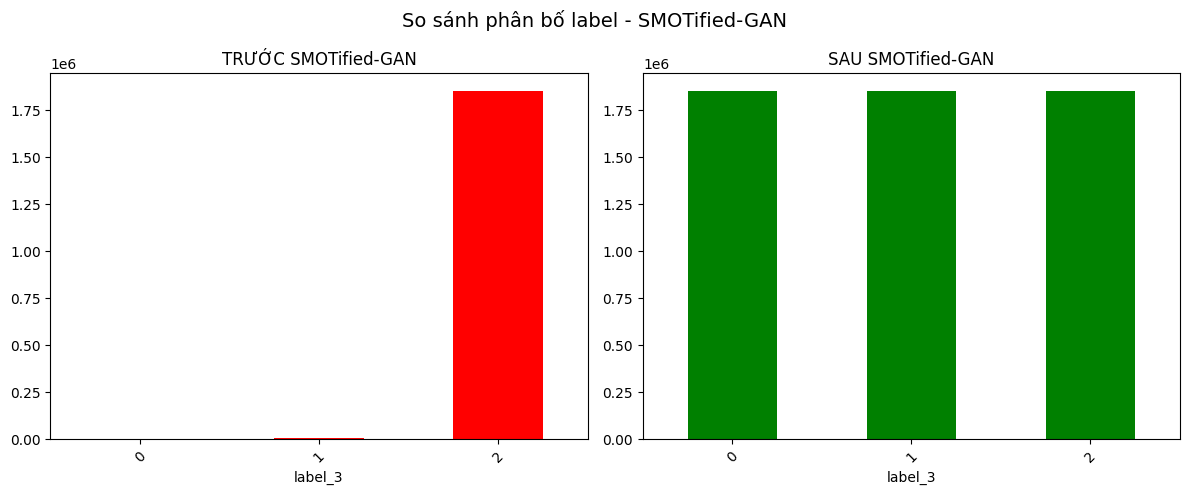

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_median[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SMOTified-GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SMOTified-GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SMOTified-GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
df_balanced.to_parquet("train_median_smotified_gan.parquet", index=False)

# Mean imoutation

In [6]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Mean/Mean/train_mean.parquet"
LABEL_COL = "label_3"

df_mean = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_mean.shape}")
df_mean

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1,140538,475,114,2020,10,30,76,2,0.0,58,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
2,125447,750,170,2020,2,12,69,2,0.0,56,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
3,24957,17,151,2020,2,16,138,2,2.0,7,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
4,977326,468,173,2020,10,30,140,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781


In [7]:
print(f"Phân bố label trước SMOTified GAN:")
print(df_mean[LABEL_COL].value_counts().sort_index())

smotified_gan = SMOTifiedGAN(verbose=True, random_state=42)

df_balanced = smotified_gan.fit_resample(df_mean, label_col="label_3", epochs=50, batch_size=512)

print(f"\nPhân bố label sau SMOTified GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SMOTified GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

========== SMOTified-GAN ==========
Device: cuda
Majority class: 2

Class distribution BEFORE:
Class 0: 1783
Class 1: 4839
Class 2: 1852997

Processing minority class 0
Minority samples : 1783
Majority samples : 1852997
SMOTE generated: 1851214 samples
Epoch [1/50] | G Loss: 2.8318 | D Loss: 2.7429
Epoch [10/50] | G Loss: 3.4170 | D Loss: 2.0704
Epoch [20/50] | G Loss: 2.8070 | D Loss: 2.8391
Epoch [30/50] | G Loss: 3.2574 | D Loss: 2.5564
Epoch [40/50] | G Loss: 4.6602 | D Loss: 1.9147
Epoch [50/50] | G Loss: 5.1167 | D Loss: 2.2635
GAN refined 1851214 samples for class 0

Processing minority class 1
Minority samples : 4839
Majority samples : 1852997
SMOTE generated: 1848158 samples
Epoch [1/50] | G Loss: 6.9954 | D Loss: 6.6355
Epoch [10/50] | G Loss: 6.5594 | D Loss: 7.5792
Epoch [20/50] | G Loss: 13.3601 | D Loss: 5.3207
Epoch [30/50] | G Loss: 10.7315 | D Loss: 4.5983
Epoch

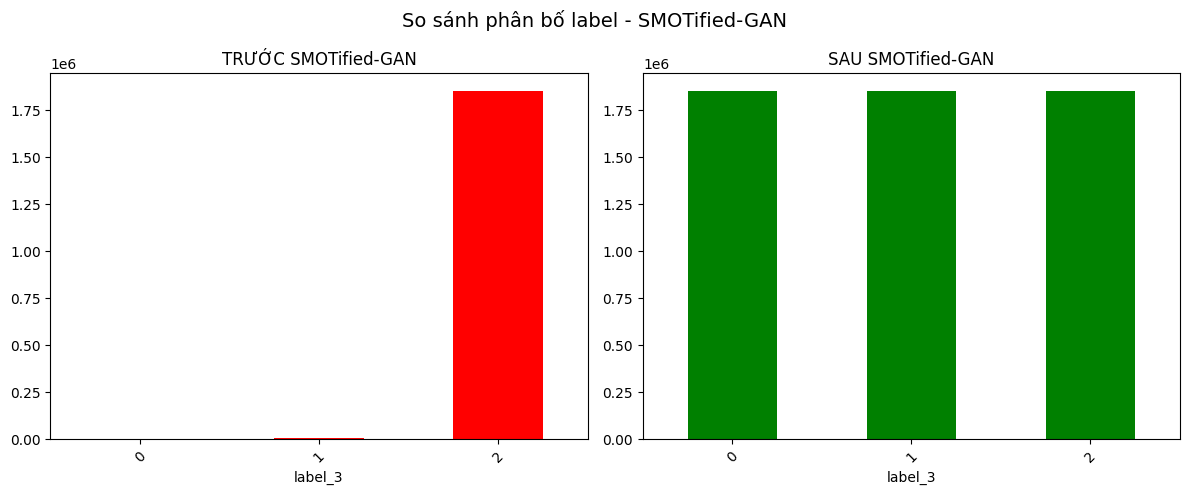

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_mean[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SMOTified-GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SMOTified-GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SMOTified-GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
df_balanced.to_parquet("train_mean_smotified_gan.parquet", index=False)

# Extra_trees imputation

In [10]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Extra_trees/Extra_trees/train_extra.parquet"
LABEL_COL = "label_3"

df_Extra_trees = pd.read_parquet(INPUT_FILE)
print(f"Đã đọc file: {df_Extra_trees.shape}")
df_Extra_trees

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176.0,2020.0,2.0,6.0,170.0,2,2.0,6.0,...,28.345097,75.224105,2.239722,0.651001,31.967399,0.010466,0.119216,0.749036,0.123232,0.743935
1,140538,475,114.0,2020.0,10.0,30.0,76.0,2,0.0,58.0,...,24.601815,77.347451,2.418864,0.657834,24.714212,0.006163,0.146233,0.768704,0.091260,0.712458
2,125447,750,170.0,2020.0,2.0,12.0,69.0,2,0.0,56.0,...,25.038668,67.816256,1.746079,0.684022,26.336268,0.004388,0.103833,0.770995,0.114709,0.704242
3,24957,17,151.0,2020.0,2.0,16.0,138.0,2,2.0,7.0,...,21.832723,61.084016,2.188559,0.651001,24.026333,0.007815,0.110005,0.761642,0.127080,0.719493
4,977326,468,173.0,2020.0,10.0,30.0,140.0,2,2.0,2.0,...,21.870573,68.990436,2.088095,0.657834,25.265029,0.003142,0.139406,0.761305,0.099424,0.738092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91.0,2019.0,12.0,31.0,52.0,2,0.0,49.0,...,48.100983,155.905533,2.164014,0.679425,25.602336,0.004796,0.163354,0.724069,0.105012,0.749764
1859615,106770,862,121.0,2020.0,9.0,1.0,31.0,2,0.0,60.0,...,40.613763,87.318300,2.086876,0.657834,31.689427,0.004874,0.097344,0.749513,0.159769,0.790002
1859616,258729,833,93.0,2020.0,4.0,13.0,91.0,2,2.0,2.0,...,21.292247,49.104277,1.740292,0.656641,27.509743,0.001563,0.099459,0.785990,0.114119,0.645251
1859617,969906,616,121.0,2020.0,9.0,1.0,37.0,2,1.0,3.0,...,36.010158,101.582165,1.676263,0.658539,25.701191,0.001337,0.098596,0.737834,0.163638,0.803611


In [11]:
print(f"Phân bố label trước SMOTified GAN:")
print(df_Extra_trees[LABEL_COL].value_counts().sort_index())

smotified_gan = SMOTifiedGAN(verbose=True, random_state=42)

df_balanced = smotified_gan.fit_resample(df_Extra_trees, label_col="label_3", epochs=50, batch_size=512)

print(f"\nPhân bố label sau SMOTified GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SMOTified GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

========== SMOTified-GAN ==========
Device: cuda
Majority class: 2

Class distribution BEFORE:
Class 0: 1783
Class 1: 4839
Class 2: 1852997

Processing minority class 0
Minority samples : 1783
Majority samples : 1852997
SMOTE generated: 1851214 samples
Epoch [1/50] | G Loss: 2.8393 | D Loss: 2.7598
Epoch [10/50] | G Loss: 3.3943 | D Loss: 2.3936
Epoch [20/50] | G Loss: 3.4095 | D Loss: 2.6247
Epoch [30/50] | G Loss: 3.5259 | D Loss: 2.7868
Epoch [40/50] | G Loss: 5.6296 | D Loss: 1.6913
Epoch [50/50] | G Loss: 4.5854 | D Loss: 2.8492
GAN refined 1851214 samples for class 0

Processing minority class 1
Minority samples : 4839
Majority samples : 1852997
SMOTE generated: 1848158 samples
Epoch [1/50] | G Loss: 7.0366 | D Loss: 6.7219
Epoch [10/50] | G Loss: 7.7250 | D Loss: 7.4330
Epoch [20/50] | G Loss: 11.2409 | D Loss: 6.7097
Epoch [30/50] | G Loss: 6.5384 | D Loss: 8.0522
Epoch 

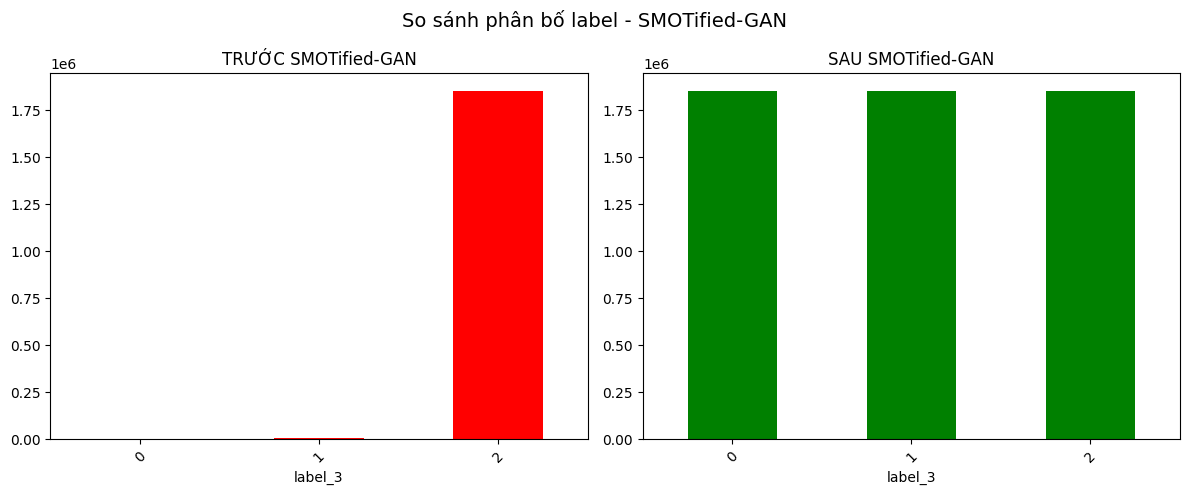

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_Extra_trees[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SMOTified-GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SMOTified-GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SMOTified-GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
df_balanced.to_parquet("train_Extra_trees_smotified_gan.parquet", index=False)